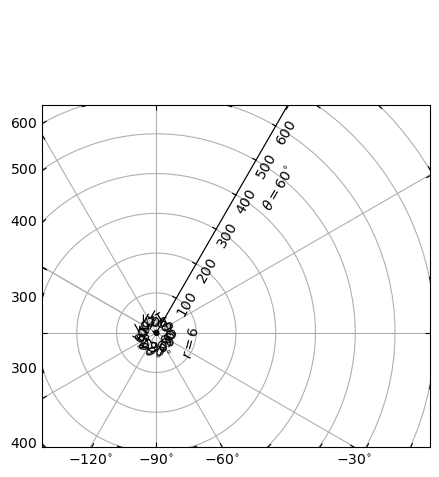

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.projections import PolarAxes
from matplotlib.transforms import Affine2D
from mpl_toolkits.axisartist import GridHelperCurveLinear, HostAxes
import mpl_toolkits.axisartist.angle_helper as angle_helper

def polar_projection_demo(fig):
    """在矩形框中进行极坐标投影示例。"""
    # 设置极坐标变换，单位转换
    transform = Affine2D().scale(np.pi / 180.) + PolarAxes.PolarTransform()

    # 设置极坐标中的极值查找器
    extreme_finder = angle_helper.ExtremeFinderCycle(20,
                                                     20,
                                                     lon_cycle=360,
                                                     lat_cycle=None,
                                                     lon_minmax=None,
                                                     lat_minmax=(0, np.inf))

    # 设置网格定位器和刻度格式器
    grid_locator = angle_helper.LocatorDMS(12)
    tick_formatter = angle_helper.FormatterDMS()

    # 创建网格助手
    grid_helper = GridHelperCurveLinear(transform,
                                        extreme_finder=extreme_finder,
                                        grid_locator1=grid_locator,
                                        tick_formatter1=tick_formatter)

    # 添加子图，使用HostAxes和网格助手
    ax1 = fig.add_subplot(axes_class=HostAxes, grid_helper=grid_helper)

    # 创建浮动坐标轴，设置极角θ为60°
    ax1.axis["lat"] = axis_theta = ax1.new_floating_axis(0, 60)
    axis_theta.label.set_text(r"$\theta = 60^{\circ}$")
    axis_theta.label.set_visible(True)

    # 创建浮动坐标轴，设置半径r为6
    ax1.axis["lon"] = axis_radius = ax1.new_floating_axis(1, 6)
    axis_radius.label.set_text(r"$r = 6$")

    # 设置坐标轴的比例和限制
    ax1.set_aspect(1.)
    ax1.set_xlim(-5, 12)
    ax1.set_ylim(-5, 10)

    # 显示网格
    ax1.grid(True)

# 创建图形并调用绘制函数
fig = plt.figure(figsize=(5, 5))
polar_projection_demo(fig)
plt.show()

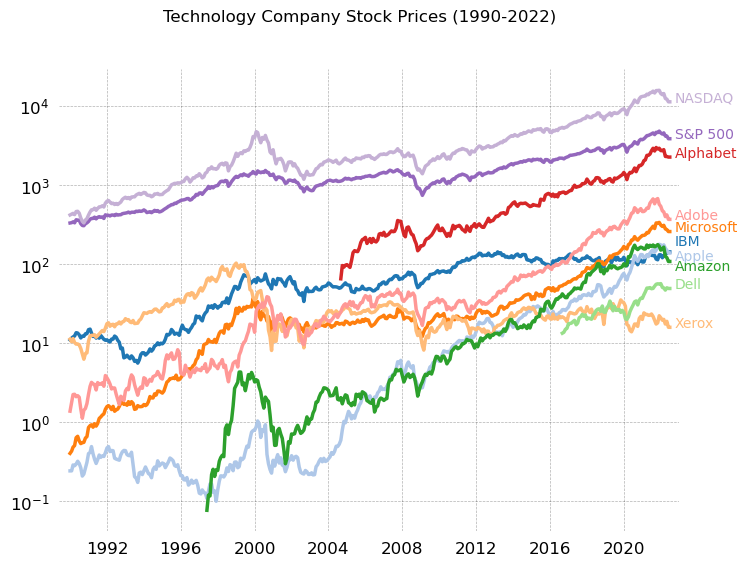

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cbook import get_sample_data
import matplotlib.transforms as mtransforms

# 设置字体以支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 加载股票数据
with get_sample_data('Stocks.csv') as file:
    stock_data = np.genfromtxt(
        file, delimiter=',', names=True, dtype=None,
        converters={0: lambda x: np.datetime64(x, 'D')}, skip_header=1)

fig, ax = plt.subplots(figsize=(8, 6))

# 设定颜色
ax.set_prop_cycle(color=[
    '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a',
    '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', '#c49c94',
    '#e377c2', '#f7b6d2', '#7f7f7f', '#c7c7c7', '#bcbd22', '#dbdb8d',
    '#17becf', '#9edae5'])

# 股票名称与代码
stocks_name = ['IBM', 'Apple', 'Microsoft', 'Xerox', 'Amazon', 'Dell',
               'Alphabet', 'Adobe', 'S&P 500', 'NASDAQ']
stocks_ticker = ['IBM', 'AAPL', 'MSFT', 'XRX', 'AMZN', 'DELL', 'GOOGL',
                 'ADBE', 'GSPC', 'IXIC']

# 手动调整标签位置
y_offsets = {k: 0 for k in stocks_ticker}
y_offsets['IBM'] = 5
y_offsets['AAPL'] = -5
y_offsets['AMZN'] = -6

# 绘制每条股票线
for nn, column in enumerate(stocks_ticker):
    good = np.nonzero(np.isfinite(stock_data[column]))
    line, = ax.plot(stock_data['Date'][good], stock_data[column][good], lw=2.5)

    y_pos = stock_data[column][-1]
    offset = y_offsets[column] / 72
    trans = mtransforms.ScaledTranslation(0, offset, fig.dpi_scale_trans)
    trans = ax.transData + trans

    ax.text(np.datetime64('2022-10-01'), y_pos, stocks_name[nn],
            color=line.get_color(), transform=trans)

ax.set_xlim(np.datetime64('1989-06-01'), np.datetime64('2023-01-01'))

# 设置中文标题
fig.suptitle("Technology Company Stock Prices (1990-2022)", ha="center")

# 隐藏图框
ax.spines[:].set_visible(False)

ax.xaxis.tick_bottom()
ax.yaxis.tick_left()
ax.set_yscale('log')
ax.grid(True, 'major', 'both', ls='--', lw=.5, c='k', alpha=.3)

ax.tick_params(axis='both', which='both', labelsize='large',
               bottom=False, top=False, labelbottom=True,
               left=False, right=False, labelleft=True)

plt.show()

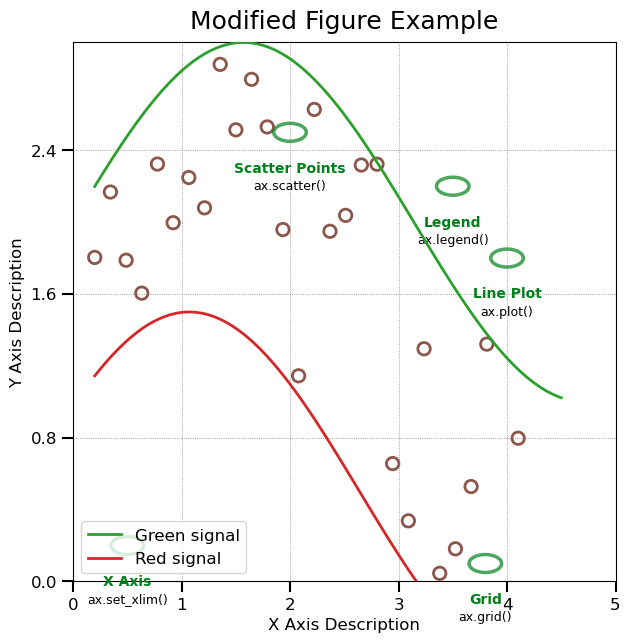

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from matplotlib.ticker import MaxNLocator

# 颜色设置
dark_green = [0, 0.5, 0.1]

# 随机数种子用于保持结果一致性
np.random.seed(42)

# 生成 X 轴上的数据点和对应的 Y 轴上的三个不同数据集
X_vals = np.linspace(0.2, 4.5, 120)
Y1_vals = 2 + np.sin(X_vals)  # 第一个信号
Y2_vals = 0.5 + np.sin(X_vals + 0.5)  # 第二个信号
Y3_vals = np.random.uniform(Y1_vals, Y2_vals, len(X_vals))  # 随机数值

# 创建图像
fig, ax = plt.subplots(figsize=(7, 7))

# 设置坐标轴的主刻度和次刻度
ax.xaxis.set_major_locator(MaxNLocator(5))
ax.yaxis.set_major_locator(MaxNLocator(4))

# 设置 x 和 y 轴的显示范围
ax.set_xlim(0, 5)
ax.set_ylim(0, 3)

# 调整刻度和标签的格式与颜色
ax.tick_params(which='major', width=1.5, length=8, labelsize=12)
ax.tick_params(which='minor', width=1.0, length=4, labelsize=8, labelcolor='0.4')

# 添加网格线
ax.grid(linestyle=":", linewidth=0.6, color='gray', zorder=-15)

# 绘制数据线
ax.plot(X_vals, Y1_vals, color='C2', lw=2, label="Green signal", zorder=10)
ax.plot(X_vals, Y2_vals, color='C3', lw=2, label="Red signal")
ax.scatter(X_vals[::4], Y3_vals[::4], s=80, marker='o', facecolor='none', edgecolor='C5', linewidths=2)

# 设置图表标题和坐标轴标签
ax.set_title("Modified Figure Example", fontsize=18, pad=10)
ax.set_xlabel("X Axis Description", fontsize=12)
ax.set_ylabel("Y Axis Description", fontsize=12)

# 显示图例
ax.legend(loc="lower left", fontsize=12)

# 注释函数，使用椭圆来标注
def add_annotation(x, y, text, annotation_code):
    ell = Ellipse((x, y), width=0.3, height=0.1, edgecolor=dark_green + [0.7], facecolor='none', linewidth=2.5)
    ax.add_patch(ell)

    ax.text(x, y - 0.2, text, ha='center', va='center', fontsize=10, color=dark_green, weight='bold')
    ax.text(x, y - 0.3, annotation_code, ha='center', va='center', fontsize=9, color='black')

# 添加多个注释，描述图形的各个部分
add_annotation(4.0, 1.8, "Line Plot", "ax.plot()")
add_annotation(0.5, 0.2, "X Axis", "ax.set_xlim()")
add_annotation(3.8, 0.1, "Grid", "ax.grid()")
add_annotation(2.0, 2.5, "Scatter Points", "ax.scatter()")
add_annotation(3.5, 2.2, "Legend", "ax.legend()")

# 显示图形
plt.show()

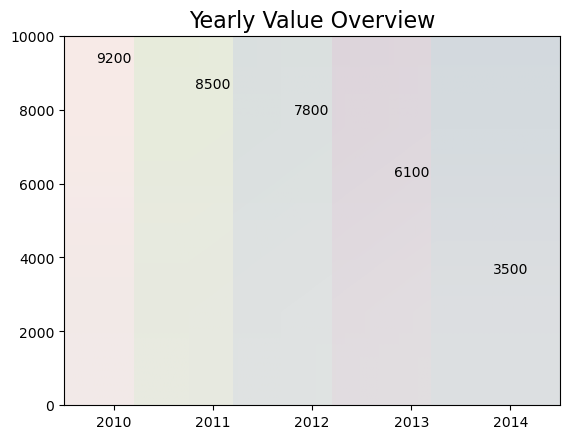

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors
from matplotlib.image import AxesImage
from matplotlib.transforms import Bbox, BboxTransformTo, TransformedBbox

# 定义盒子的类，用于创建渐变效果
class GradientBox:
    def __init__(self, color):
        # 使用给定的颜色创建渐变
        base_color = np.array(mcolors.to_rgb(color))
        self.box_image = np.ones((100, 100, 4))  # 100x100 图片大小
        self.box_image[:, :, :3] = base_color  # 设置颜色
        self.box_image[:, :, 3] = np.linspace(0.1, 1, 100)[:, None]  # alpha 渐变

    def get_resized_image(self, height_scale):
        # 调整盒子的高度
        height = int(self.box_image.shape[0] * height_scale)
        return np.resize(self.box_image, (height, self.box_image.shape[1], 4))


class GradientBoxImage(AxesImage):
    def __init__(self, ax, bbox, color, **kwargs):
        super().__init__(ax, **kwargs)
        self.bbox = bbox
        self.gradient_box = GradientBox(color)
        self.set_transform(BboxTransformTo(bbox))

    def draw(self, renderer):
        # 根据高度调整图片的缩放比例
        height_factor = self.bbox.height / self.bbox.width
        resized_image = self.gradient_box.get_resized_image(height_factor)
        self.set_array(resized_image)
        super().draw(renderer)


# 主函数，生成柱状图
def plot_ribbon_boxes():
    fig, ax = plt.subplots()

    years = np.arange(2010, 2015)
    values = [9200, 8500, 7800, 6100, 3500]  # 模拟一些高度数据
    colors = ["#FF5733", "#33FF57", "#3357FF", "#FF33A1", "#33FFF0"]  # 各种颜色

    for year, value, color in zip(years, values, colors):
        bbox0 = Bbox.from_extents(year - 0.4, 0, year + 0.4, value)
        bbox = TransformedBbox(bbox0, ax.transData)
        ax.add_artist(GradientBoxImage(ax, bbox, color, interpolation="bilinear"))
        ax.annotate(f"{value}", (year, value), ha="center", va="bottom")

    # 设置 X, Y 轴范围
    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_ylim(0, 10000)

    # 设置背景渐变
    bg_color = np.zeros((2, 2, 4))  # 背景图片 (2x2)
    bg_color[:, :, :3] = [0.9, 0.9, 0.9]  # 背景色调
    bg_color[:, :, 3] = [[0.3, 0.5], [0.5, 0.7]]  # Alpha 透明度
    ax.imshow(bg_color, interpolation="bilinear", zorder=0.1, extent=(0, 1, 0, 1), transform=ax.transAxes)

    plt.title("Yearly Value Overview", fontsize=16)  # 设置标题
    plt.show()


# 调用主函数绘制图形
plot_ribbon_boxes()

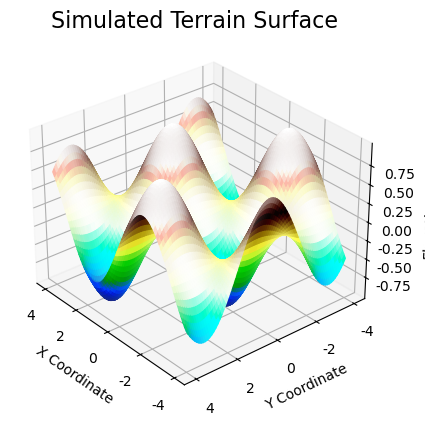

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LightSource
from matplotlib import cm

# 生成模拟地形数据
def generate_terrain_data(rows, cols):
    x = np.linspace(-5, 5, cols)
    y = np.linspace(-5, 5, rows)
    x, y = np.meshgrid(x, y)
    
    # 使用正弦函数生成波浪形地形
    z = np.sin(x) * np.cos(y)
    
    return x, y, z

# 设置数据规模
nrows, ncols = 100, 100
x, y, z = generate_terrain_data(nrows, ncols)

# 选择部分区域进行可视化
region = np.s_[10:90, 10:90]
x, y, z = x[region], y[region], z[region]

# 创建 3D 图表
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

# 设置光源和阴影效果
light_source = LightSource(azdeg=225, altdeg=45)
# 使用指定的颜色映射和光照效果
rgb = light_source.shade(z, cmap=cm.terrain, vert_exag=0.5, blend_mode='overlay')

# 绘制表面图
surface = ax.plot_surface(x, y, z, facecolors=rgb, rstride=1, cstride=1, antialiased=True, shade=False)

# 设置图形标题和标签
ax.set_title('Simulated Terrain Surface', fontsize=16)
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Elevation')

# 调整视角
ax.view_init(elev=30, azim=140)

# 显示图形
plt.show()

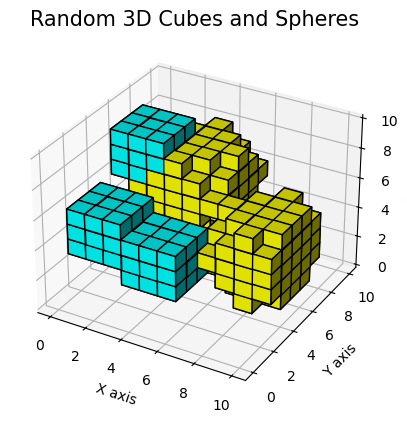

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 生成三维坐标系中的点集
x, y, z = np.indices((10, 10, 10))

# 随机生成多个立方体
def generate_cubes(x, y, z, num_cubes=3, cube_size=2):
    cubes = np.zeros_like(x, dtype=bool)
    for _ in range(num_cubes):
        x_start = np.random.randint(0, x.shape[0] - cube_size)
        y_start = np.random.randint(0, y.shape[1] - cube_size)
        z_start = np.random.randint(0, z.shape[2] - cube_size)
        cubes |= (x >= x_start) & (x < x_start + cube_size) & \
                 (y >= y_start) & (y < y_start + cube_size) & \
                 (z >= z_start) & (z < z_start + cube_size)
    return cubes

# 生成球体
def generate_spheres(x, y, z, num_spheres=2, radius=3):
    spheres = np.zeros_like(x, dtype=bool)
    for _ in range(num_spheres):
        center_x, center_y, center_z = np.random.randint(0, x.shape[0], size=3)
        distance = np.sqrt((x - center_x)**2 + (y - center_y)**2 + (z - center_z)**2)
        spheres |= distance < radius
    return spheres

# 组合生成的立方体和球体
cubes = generate_cubes(x, y, z, num_cubes=4, cube_size=3)
spheres = generate_spheres(x, y, z, num_spheres=2, radius=3)

# 将立方体和球体组合成一个三维数组
voxelarray = cubes | spheres

# 定义颜色数组，并为不同的几何形状指定不同的颜色
colors = np.empty(voxelarray.shape, dtype=object)
colors[cubes] = 'cyan'  # 立方体颜色
colors[spheres] = 'yellow'  # 球体颜色

# 创建3D绘图并设置投影为3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制3D体素图
ax.voxels(voxelarray, facecolors=colors, edgecolor='k')

# 设置标题和标签
ax.set_title('Random 3D Cubes and Spheres', fontsize=15)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

# 显示图像
plt.show()

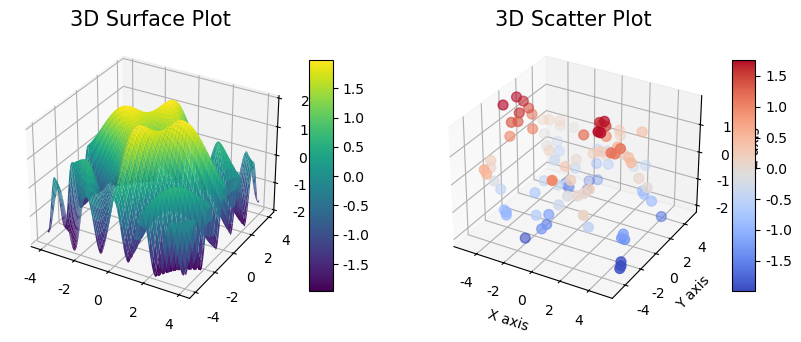

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# 创建一个宽高比为2:1的画布
fig = plt.figure(figsize=(10, 5))


# 第一个子图：3D曲面图
# 设置第一个子图的3D坐标轴
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# 生成X和Y的网格数据，并计算Z值（使用sin和cos函数生成波形图）
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2)) + np.cos(X*Y)  # 自定义波动函数

# 使用'viridis'色彩映射绘制3D曲面
surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor='none')
ax1.set_title('3D Surface Plot', fontsize=15)
ax1.set_zlim(-2, 2)

# 添加颜色条以展示高度变化
fig.colorbar(surf, ax=ax1, shrink=0.6, aspect=10)

# 第二个子图：3D散点图
# 设置第二个子图的3D坐标轴
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# 随机生成散点数据
np.random.seed(0)
x2 = np.random.uniform(-5, 5, 100)
y2 = np.random.uniform(-5, 5, 100)
z2 = np.sin(x2) + np.cos(y2)

# 使用散点图展示3D数据点，设置点的大小和颜色
scatter = ax2.scatter(x2, y2, z2, c=z2, cmap=cm.coolwarm, s=50)

# 设置标题与轴标签
ax2.set_title('3D Scatter Plot', fontsize=15)
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
ax2.set_zlabel('Z axis')

# 为散点图添加颜色条
fig.colorbar(scatter, ax=ax2, shrink=0.6, aspect=10)

# 显示图像
plt.show()

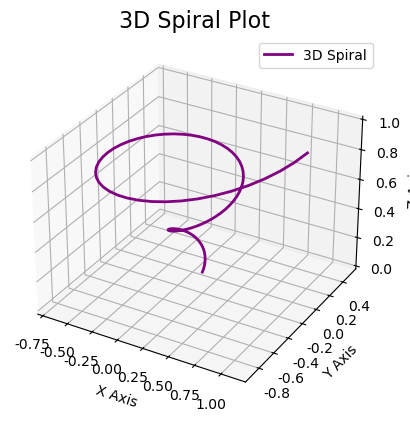

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# 生成螺旋线数据
theta = np.linspace(0, 4 * np.pi, 100)  # 生成更多的角度数据形成螺旋
z = np.linspace(0, 1, 100)  # z轴上数据从0到1的渐变
r = z**2 + 0.1  # 半径随z的平方变化，形成螺旋

# 根据极坐标生成x和y
x = r * np.cos(theta)
y = r * np.sin(theta)

# 创建3D绘图对象
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

# 绘制三维螺旋线
ax.plot(x, y, z, color='purple', lw=2, label="3D Spiral")

# 设置标题和轴标签
ax.set_title("3D Spiral Plot", fontsize=16)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# 增加图例
ax.legend()

# 显示图形
plt.show()

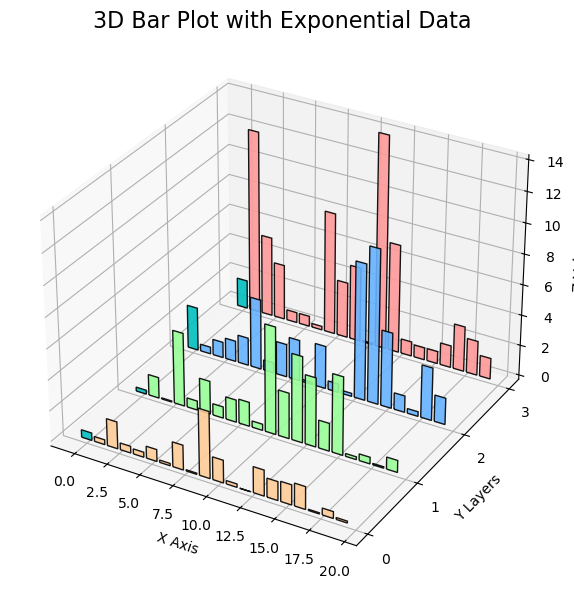

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# 固定随机数种子以确保结果可复现
np.random.seed(42)

# 创建绘图窗口和3D坐标轴
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

# 定义颜色列表和对应的y轴坐标
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']  # 使用渐变色
yticks = [3, 2, 1, 0]

# 绘制每一层的柱状图
def plot_layer(ax, color, layer_idx):
    """绘制给定层的柱状图"""
    xs = np.arange(20)
    # 使用指数函数和随机数生成不同的柱状图数据
    ys = np.random.exponential(scale=1.0, size=20) * (layer_idx + 1)
    
    # 设置颜色，首个柱子颜色略有区别
    cs = [color] * len(xs)
    cs[0] = 'c'  # 强调第一个柱子
    
    # 绘制柱状图
    ax.bar(xs, ys, zs=layer_idx, zdir='y', color=cs, alpha=0.9, edgecolor='k')

# 遍历每个颜色层并绘制图形
for idx, color in enumerate(colors):
    plot_layer(ax, color, yticks[idx])

# 设置坐标轴标签和标题
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Layers')
ax.set_zlabel('Z Values')
ax.set_title('3D Bar Plot with Exponential Data', fontsize=16)

# 在y轴上设置离散的标签值
ax.set_yticks(yticks)

# 显示图形
plt.tight_layout()
plt.show()

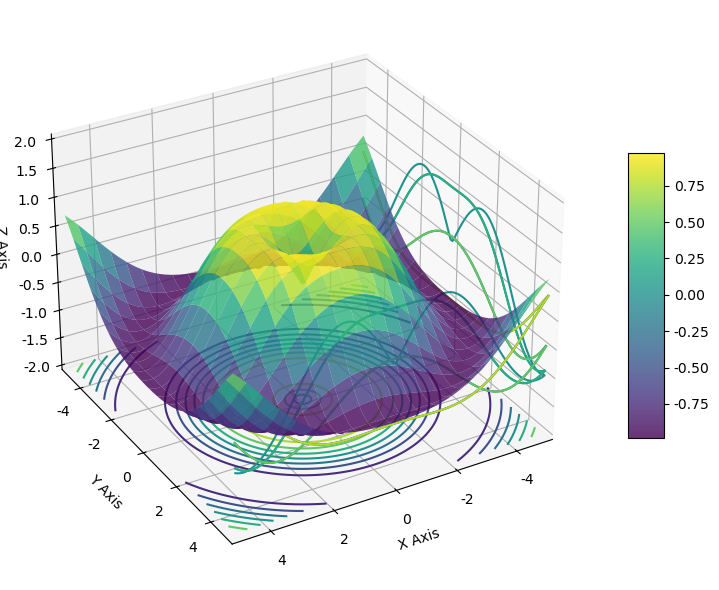

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# 创建一个用于绘制3D表面的函数
def create_3d_surface(ax, X, Y, Z):
    """绘制3D表面和等高线投影"""
    # 绘制半透明的3D表面
    surface = ax.plot_surface(X, Y, Z, rstride=5, cstride=5, 
                              cmap='viridis', edgecolor='none', alpha=0.8)

    # 添加在各个坐标平面上的等高线投影
    ax.contour(X, Y, Z, zdir='z', offset=-2, cmap='viridis')
    ax.contour(X, Y, Z, zdir='x', offset=-5, cmap='viridis')
    ax.contour(X, Y, Z, zdir='y', offset=5, cmap='viridis')

    return surface

# 生成自定义的三维数据
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))  # 使用径向正弦函数生成Z数据

# 创建绘图窗口
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')

# 调用绘图函数创建3D表面
surface = create_3d_surface(ax, X, Y, Z)

# 设置坐标轴范围和标签
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-2, 2])
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# 添加颜色条以表示高度
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=8)

# 设置观察角度
ax.view_init(elev=30, azim=60)

# 显示图形
plt.tight_layout()
plt.show()

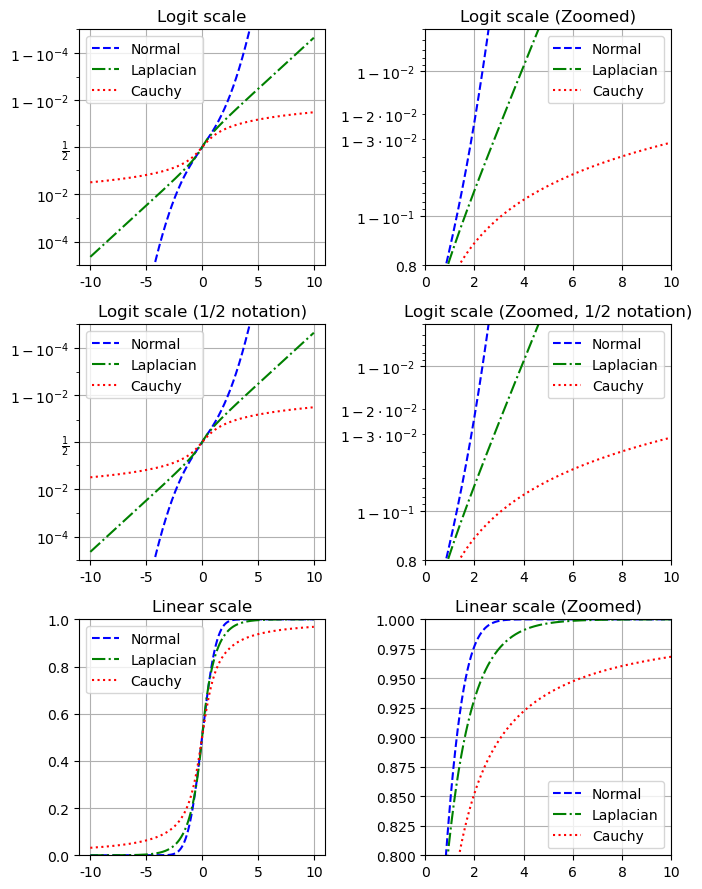

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf  # 从 scipy.special 模块导入 erf 函数

# 计算三种分布的CDF函数
def calculate_cdfs(x):
    """计算正态分布、拉普拉斯分布和柯西分布的CDF"""
    cdf_normal = 0.5 * (1 + erf(x / np.sqrt(2)))  # 正态分布
    cdf_laplacian = np.where(x < 0, 0.5 * np.exp(x), 1 - 0.5 * np.exp(-x))  # 拉普拉斯分布
    cdf_cauchy = np.arctan(x) / np.pi + 0.5  # 柯西分布
    return cdf_normal, cdf_laplacian, cdf_cauchy

# 画图函数，支持不同的尺度
def plot_cdfs(ax, x, cdfs, title, scale='linear', xlim=None, ylim=None):
    """在指定轴上绘制不同分布的CDF"""
    cdf_norm, cdf_laplacian, cdf_cauchy = cdfs
    ax.plot(x, cdf_norm, label="Normal", color="blue", linestyle='--')
    ax.plot(x, cdf_laplacian, label="Laplacian", color="green", linestyle='-.')
    ax.plot(x, cdf_cauchy, label="Cauchy", color="red", linestyle=':')
    
    ax.set(title=title)
    ax.set_yscale(scale)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend()
    ax.grid(True)

# 生成数据
x_max = 10
x_values = np.linspace(-x_max, x_max, 10000)
cdfs = calculate_cdfs(x_values)

# 创建图形和子图
fig, axes = plt.subplots(3, 2, figsize=(7, 9))

# 第一行：Logit 尺度
plot_cdfs(axes[0, 0], x_values, cdfs, title="Logit scale", scale='logit', ylim=(1e-5, 1 - 1e-5))
plot_cdfs(axes[0, 1], x_values, cdfs, title="Logit scale (Zoomed)", scale='logit', xlim=(0, x_max), ylim=(0.8, 1 - 5e-3))

# 第二行：Logit 尺度，带 1/2 表示
plot_cdfs(axes[1, 0], x_values, cdfs, title="Logit scale (1/2 notation)", scale='logit', ylim=(1e-5, 1 - 1e-5))
plot_cdfs(axes[1, 1], x_values, cdfs, title="Logit scale (Zoomed, 1/2 notation)", scale='logit', xlim=(0, x_max), ylim=(0.8, 1 - 5e-3))

# 第三行：线性尺度
plot_cdfs(axes[2, 0], x_values, cdfs, title="Linear scale", scale='linear', ylim=(0, 1))
plot_cdfs(axes[2, 1], x_values, cdfs, title="Linear scale (Zoomed)", scale='linear', xlim=(0, x_max), ylim=(0.8, 1))

# 调整布局
fig.tight_layout()
plt.show()